In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Heart Disease Prediction using Naive Bayes
Dataset shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Basic statistics:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



Columns in dataset:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Target column identified as: HeartDisease

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

Data Visualization
-----------------


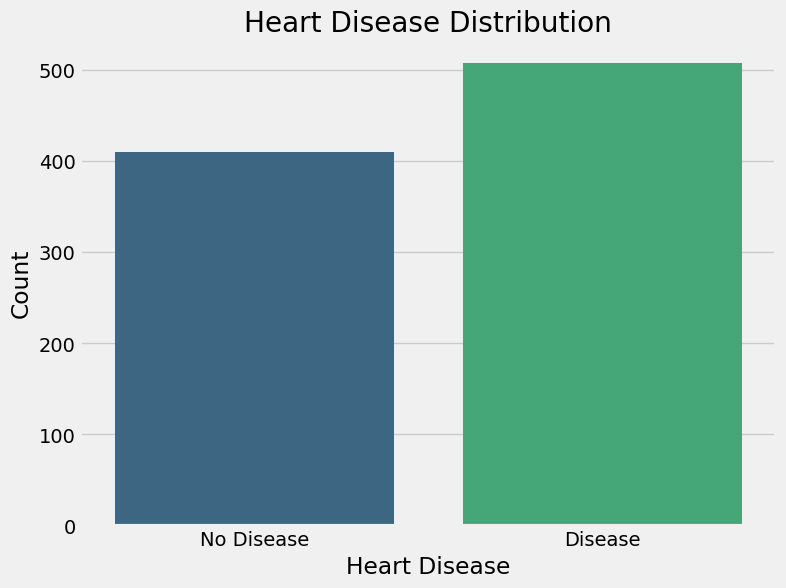

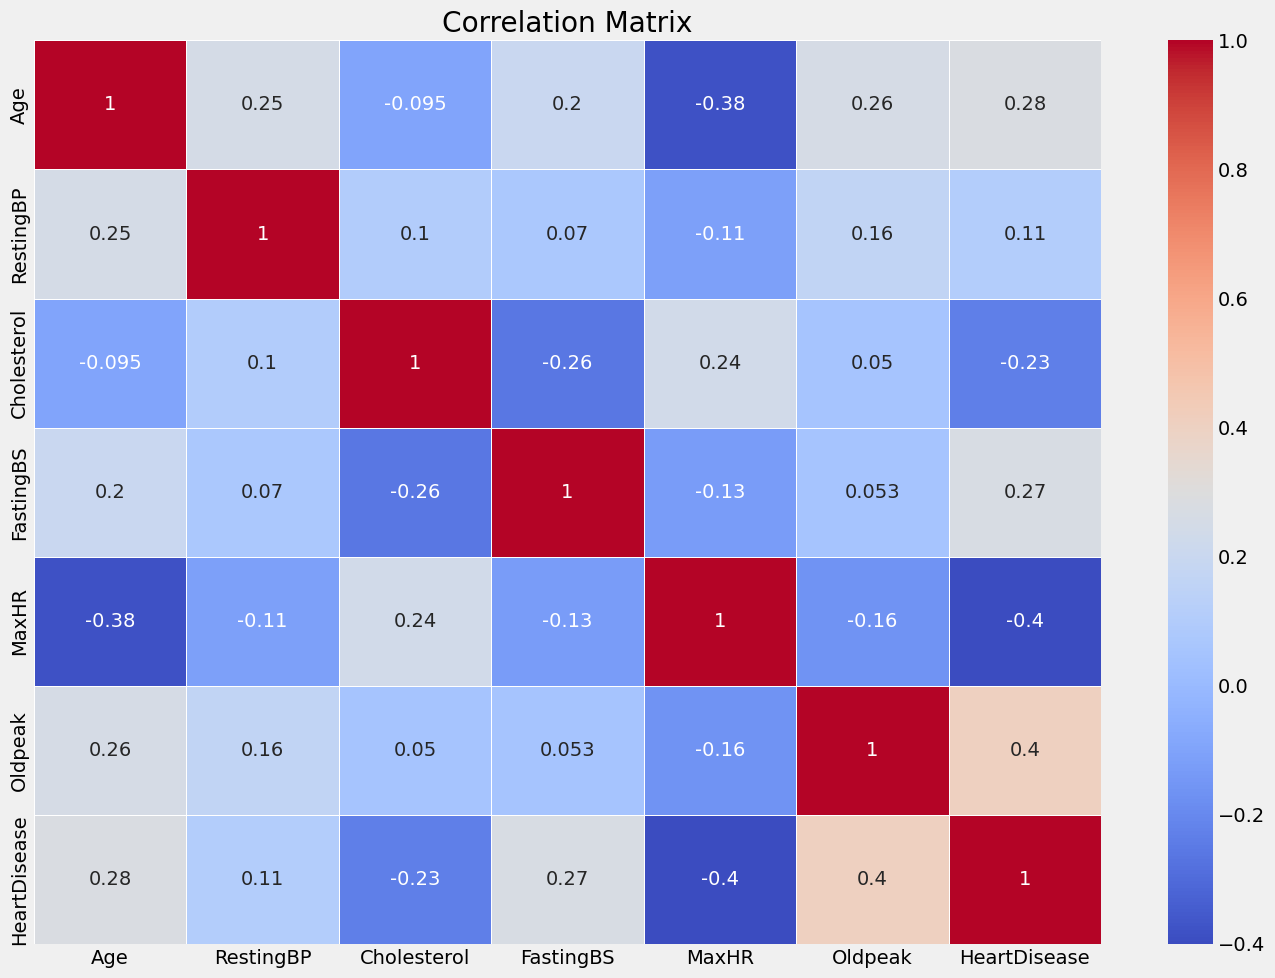

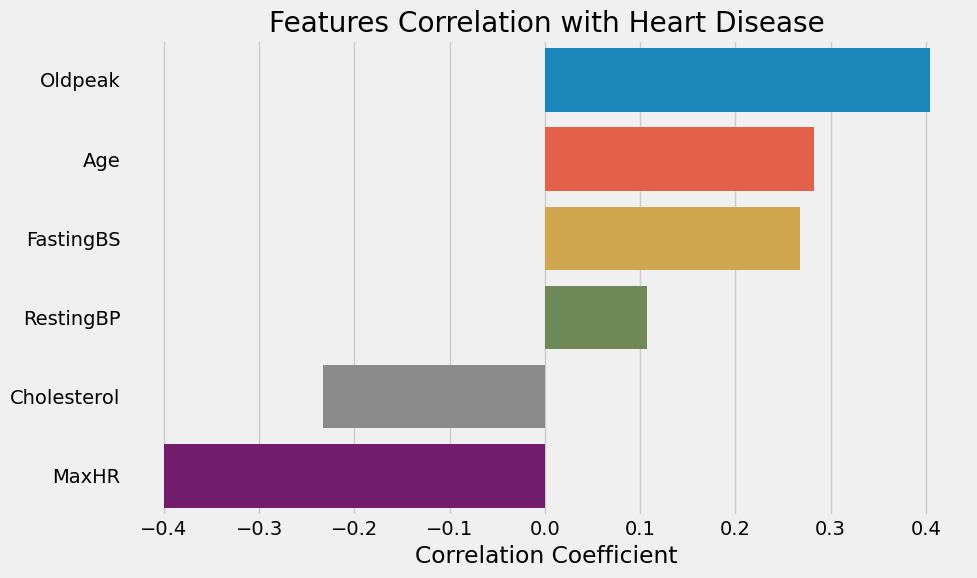


Feature Selection
----------------
Categorical columns found: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
After one-hot encoding: (918, 15)

Applying MinMaxScaler to transform data to non-negative range...
Selected top 8 features:
1. FastingBS
2. MaxHR
3. Sex_M
4. ChestPainType_ATA
5. ChestPainType_NAP
6. ExerciseAngina_Y
7. ST_Slope_Flat
8. ST_Slope_Up

Data Preprocessing
-----------------
Training set shape: (734, 8)
Testing set shape: (184, 8)

Model Training and Evaluation
--------------------------
Cross-validation accuracy: 0.8515 (±0.0210)
Test accuracy: 0.8424

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        82
           1       0.89      0.81      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184


Model saved to Kaggle working directory


In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.feature_selection import SelectKBest, chi2
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('fivethirtyeight')
%matplotlib inline

print("Heart Disease Prediction using Naive Bayes")
print("=========================================")

# Load the dataset
df = pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
display(df.describe())

# Check column names and target variable
print("\nColumns in dataset:")
print(df.columns.tolist())

# Identify the target column (assuming it's named 'HeartDisease')
target_column = 'HeartDisease' if 'HeartDisease' in df.columns else df.columns[-1]
print(f"\nTarget column identified as: {target_column}")

# Check target distribution
print("\nTarget distribution:")
print(df[target_column].value_counts())
print(df[target_column].value_counts(normalize=True) * 100)

# Data Visualization
print("\nData Visualization")
print("-----------------")

# Target distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=target_column, data=df, palette='viridis')
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
numerical_cols.remove(target_column) if target_column in numerical_cols else None

# Plot numerical features correlation with target
if len(numerical_cols) > 0:
    plt.figure(figsize=(14, 10))
    correlation = df[numerical_cols + [target_column]].corr(numeric_only=True)
    sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

    # Top features correlated with target
    plt.figure(figsize=(10, 6))
    correlation_with_target = correlation[target_column].sort_values(ascending=False)
    correlation_with_target = correlation_with_target.drop(target_column)
    sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index)
    plt.title('Features Correlation with Heart Disease')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()

# Feature Selection

print("\nFeature Selection")
print("----------------")

X = df.drop(target_column, axis=1)
y = df[target_column]

if len(categorical_cols) > 0:
    print(f"Categorical columns found: {categorical_cols}")
    X = pd.get_dummies(X, drop_first=True)
    print(f"After one-hot encoding: {X.shape}")

# Transform data to non-negative using MinMaxScaler before chi2
print("\nApplying MinMaxScaler to transform data to non-negative range...")
mm_scaler = MinMaxScaler()
X_scaled = mm_scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# apply chi2 feature selection on the scaled data
k_best = min(8, len(X.columns))  # Select top 8 features or all if less than 8
selector = SelectKBest(chi2, k=k_best)
X_new = selector.fit_transform(X_scaled_df, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print(f"Selected top {k_best} features:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

# Create a new dataframe with selected features
X_selected = X[selected_features]

# Data Preprocessing
print("\nData Preprocessing")
print("-----------------")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation
print("\nModel Training and Evaluation")
print("--------------------------")

# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()

# Cross-validation
cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = nb_model.predict(X_test_scaled)
y_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save the model
import joblib
joblib.dump(nb_model, '/kaggle/working/naive_bayes_heart_disease_model.pkl')
joblib.dump(scaler, '/kaggle/working/scaler.pkl')
joblib.dump(selected_features, '/kaggle/working/selected_features.pkl')

print("\nModel saved to Kaggle working directory")